### Lab 4: Generating CDFs

#### Author: Liam Hopkins

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng()

In [2]:
def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_ecdf_vs_cdf(samples, cdf, grid=None, title="", xlabel="", discrete=False, logx=False):
    x, y = ecdf_xy(samples)
    fig, ax = plt.subplots()
    ax.step(x, y, where="post", lw=2, label="simulation ECDF")

    if grid is None:
        lo, hi = np.quantile(x, [0.001, 0.999])
        grid = np.linspace(lo, hi, 400)
    if discrete:
        ax.step(grid, cdf(grid), where="post", lw=2, label="scipy CDF")
    else:
        ax.plot(grid, cdf(grid), lw=2, label="scipy CDF")

    if logx:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cumulative probability")
    ax.legend()
    return ax

#### Question 1

In [3]:
# Setting up a grid
k = 20
grid = np.linspace(0, 1, k+1)

# Drawing a point at random with equal probability
point = rng.choice(grid)
print(point)

0.55


We will now perform the above process $n = 5,000$ times, creating a grid and drawing a random point. We will then plot the ECDF of the draws. We will continue to use $K = 20$.

In [4]:
values = []
n = 5000

for i in range(n):
    grid = np.linspace(0, 1, k+1)
    point = rng.choice(grid)
    values.append(point)

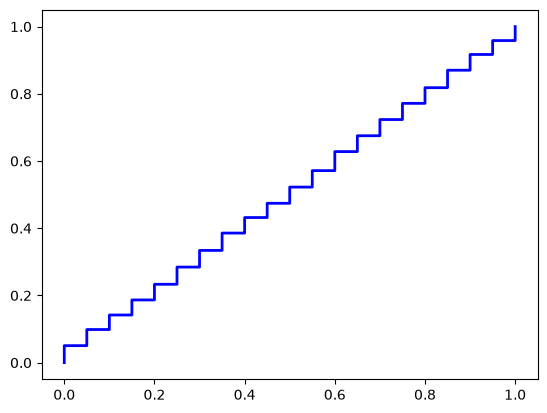

In [5]:
x, y = ecdf_xy(values)
plt.step(x, y, where='post', color='blue', lw=2)

We will now repeat with a larger $K$.

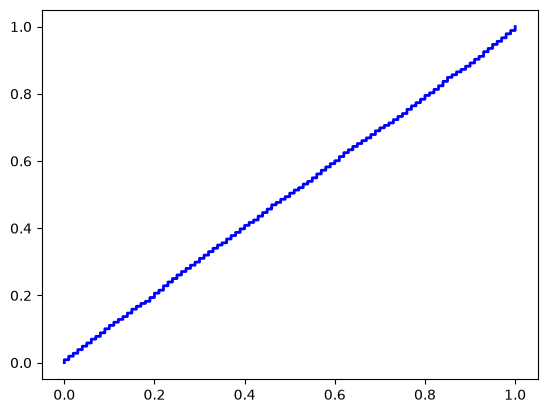

In [6]:
values = []
n = 5000
k = 100     # large K

for i in range(n):
    grid = np.linspace(0, 1, k+1)
    point = rng.choice(grid)
    values.append(point)

x, y = ecdf_xy(values)
plt.step(x, y, where='post', color='blue', lw=2)

As we can see, the ECDF of our simulation resembles a straight line, which is the CDF of the uniform distribution. We can confirm this by comparing our ECDF to the CDF of the uniform distribution using scipy.

<Axes: title={'center': 'CLT from binomial counts'}, xlabel='standardized count', ylabel='cumulative probability'>

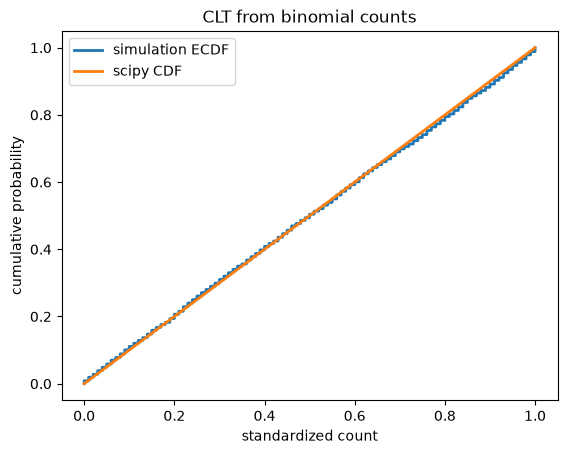

In [7]:
normal = stats.uniform(0, 1)
plot_ecdf_vs_cdf(values, normal.cdf, grid=np.linspace(0, 1, 500), title="CLT from binomial counts", xlabel="standardized count")

As shown above, the ECDF of our simulation is very similar to the CDF of the uniform distribution. Therefore, we can conclude that this approaches the uniform distribution as $K$ increases.

#### Question 2

In [8]:
# Drawing 32 values from Uniform[-sqrt(3), sqrt(3)]
n = 32
sample = stats.uniform.rvs(loc=-np.sqrt(3), scale=2 * np.sqrt(3), size=n)

# Computing the sample mean and multiplying by np.sqrt(n)
mean = np.mean(sample)
value = mean * np.sqrt(n)
print(value)

-1.5092767289790645


We will now repeat the above process $b = 5,000$ times and plot the ECDF.

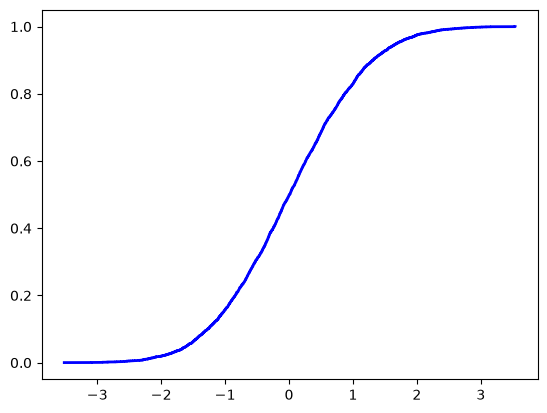

In [9]:
values = []
b = 5000

for i in range(b):
    sample = stats.uniform.rvs(loc=-np.sqrt(3), scale=2 * np.sqrt(3), size=n)
    mean = np.mean(sample)
    value = mean * np.sqrt(n)
    values.append(value)

x, y = ecdf_xy(values)
plt.step(x, y, where='post', color='blue', lw=2)

We will now repeat with a larger $n$.

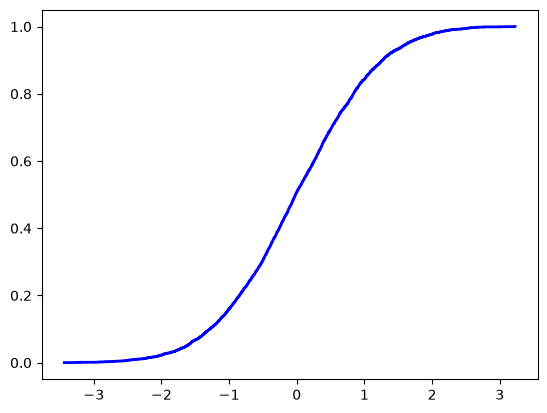

In [10]:
values = []
b = 5000
n = 500     # Large n

for i in range(b):
    sample = stats.uniform.rvs(loc=-np.sqrt(3), scale=2 * np.sqrt(3), size=n)
    mean = np.mean(sample)
    value = mean * np.sqrt(n)
    values.append(value)

x, y = ecdf_xy(values)
plt.step(x, y, where='post', color='blue', lw=2)

The above plot seems similar to a normal distribution. We can confirm this by comparing our ECDF to the CDF of the normal distribution using scipy.

<Axes: title={'center': 'CLT from binomial counts'}, xlabel='standardized count', ylabel='cumulative probability'>

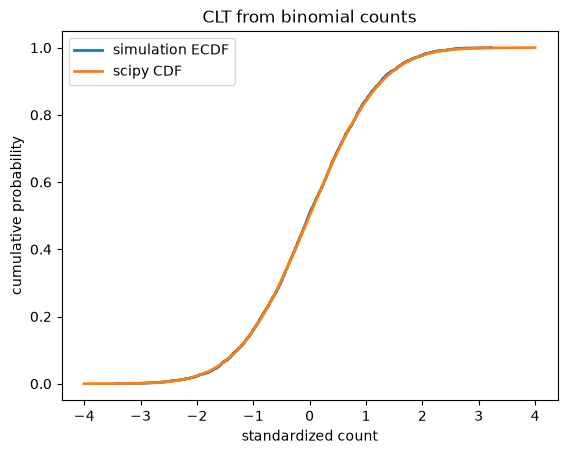

In [11]:
normal = stats.norm(0, 1)
plot_ecdf_vs_cdf(values, normal.cdf, grid=np.linspace(-4, 4, 500), title="CLT from binomial counts", xlabel="standardized count")

As we can see above, our simulation's ECDF is very similar to the CDF of the normal distribution. Therefore, we can conclude that this approaches the normal distribution as $n$ increases.

#### Question 3

In [12]:
# One sample of 40 coin flips
n = 40
p = 0.5
b = 1

counts = rng.binomial(n, p, size=b)
print(f'Number of heads: {counts[0]}, Number of tails: {n - counts[0]}')

Number of heads: 17, Number of tails: 23


In [13]:
# Subtracting the expected number of heads, n * p
expected = n * p
value = counts[0] - expected

print(f'Final count minus expected heads: {value}')

Final count minus expected heads: -3.0


In [14]:
# Divide by the standard deviation
sd = np.sqrt(n * p * (1-p))

value = value / sd
print(f'Current value / sd: {value}')

Current value / sd: -0.9486832980505138


We will now repeat the above process $b = 5,000$ times and plot the ECDF.

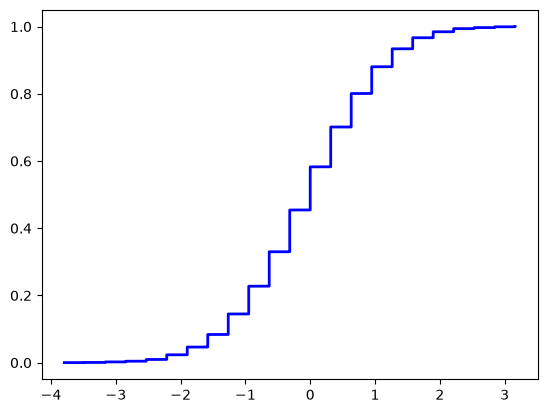

In [15]:
values = []
B = 5000

for i in range(B):
    expected = n * p
    counts = rng.binomial(n, p, size=b)
    value = counts[0] - expected
    sd = np.sqrt(n * p * (1-p))

    value = value / sd
    values.append(value)
    
x, y = ecdf_xy(values)
plt.step(x, y, where='post', color='blue', lw=2)

We will now repeat with a larger $n$.

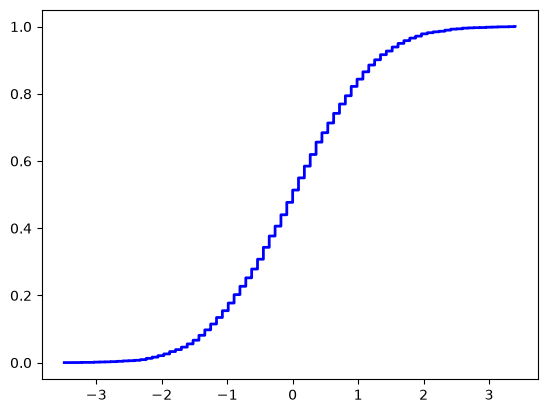

In [16]:
values = []
n = 500

for i in range(B):
    expected = n * p
    counts = rng.binomial(n, p, size=b)
    value = counts[0] - expected
    sd = np.sqrt(n * p * (1-p))

    value = value / sd
    values.append(value)
    
x, y = ecdf_xy(values)
plt.step(x, y, where='post', color='blue', lw=2)

The above plot seems similar to a normal distribution. We can confirm this by comparing our ECDF to the CDF of the normal distribution using scipy.

<Axes: title={'center': 'CLT from binomial counts'}, xlabel='standardized count', ylabel='cumulative probability'>

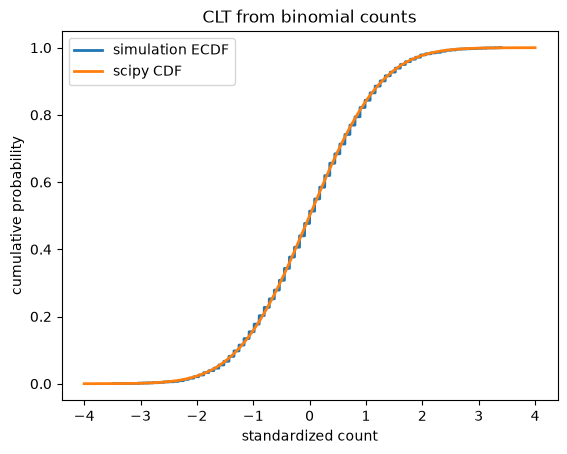

In [17]:
normal = stats.norm(0, 1)
plot_ecdf_vs_cdf(values, normal.cdf, grid=np.linspace(-4, 4, 500), title="CLT from binomial counts", xlabel="standardized count")

As we can see above, our simulation's ECDF is very similar to the CDF of the normal distribution. Therefore, we can conclude that this approaches the normal distribution as $n$ increases.

Now lets take a look at the effect of changing $p$. For this demonstration, will take two samples with $n = 40$ coin flips: one where $p = 0.5$ and one where $p = 0.002$. Then we will plot the two ECDFs and compare them.

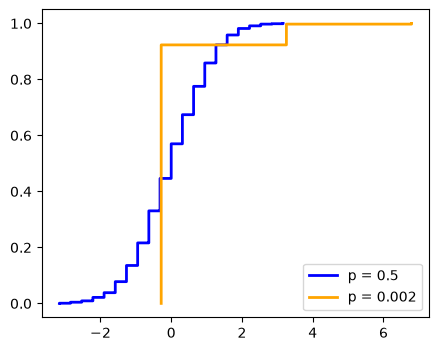

In [18]:
values = []
n = 40
pA = 0.5
pB = 0.002
fig, ax = plt.subplots(figsize=(5, 4))

for i in range(B):
    expected = n * pA
    counts = rng.binomial(n, pA, size=b)
    value = counts[0] - expected
    sd = np.sqrt(n * pA * (1-pA))

    value = value / sd
    values.append(value)
    
x, y = ecdf_xy(values)
ax.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}")

values = []

for i in range(B):
    expected = n * pB
    counts = rng.binomial(n, pB, size=b)
    value = counts[0] - expected
    sd = np.sqrt(n * pB * (1-pB))

    value = value / sd
    values.append(value)
    
x, y = ecdf_xy(values)
ax.step(x, y, where='post', color='orange', lw=2, label=f"p = {pB}")
ax.legend()
plt.show()

Based on the plot above, it appears changing the probability does change the distribution of our ECDF. The sample begins to look more like an exponential distribution after the sharp decrease in $p$. Now lets try it again increasing $p$ to $0.95$.

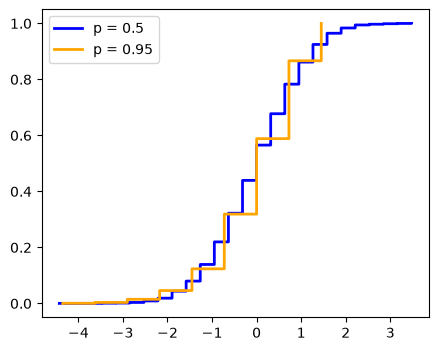

In [19]:
values = []
n = 40
pA = 0.5
pB = 0.95
fig, ax = plt.subplots(figsize=(5, 4))

for i in range(B):
    expected = n * pA
    counts = rng.binomial(n, pA, size=b)
    value = counts[0] - expected
    sd = np.sqrt(n * pA * (1-pA))

    value = value / sd
    values.append(value)
    
x, y = ecdf_xy(values)
ax.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}")

values = []

for i in range(B):
    expected = n * pB
    counts = rng.binomial(n, pB, size=b)
    value = counts[0] - expected
    sd = np.sqrt(n * pB * (1-pB))

    value = value / sd
    values.append(value)
    
x, y = ecdf_xy(values)
ax.step(x, y, where='post', color='orange', lw=2, label=f"p = {pB}")
ax.legend()
plt.show()

Once again, increasing $p$ still shows a change. Using a very large value of $p$, we see that the plot no longer curves out toward the x direction as it approaches 1. Now it seems to shoot up toward 1 continuously. Based on what we've found, it seems changing $p$ does affect the distribution as $n$ increases.

#### Question 7

In [20]:
s = 1
k = 100000      # number of cities

# Creating my ranks. The numbers are printed as floats.
r = np.linspace(1, k, k)

# Calculating the sizes
sizes = (k/r) ** s

# Randomly selecting a rank, then grabbing its corresponding size
point = int(rng.choice(r))
size = sizes[point - 1]
print(size)

3.9883540063015994


We will perform the above simulation $n=5000$ times and plot the ECDF of the simulated sizes.

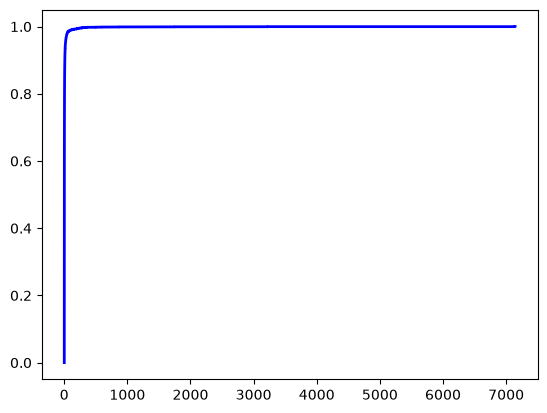

In [21]:
values = []
n = 5000

for i in range(n):
    point = int(rng.choice(r))
    size = sizes[point - 1]
    values.append(size)
    
    
x, y = ecdf_xy(values)
plt.step(x, y, where='post', color='blue', lw=2)

The above plot seems similar to a exponential distribution. We can confirm this by comparing our ECDF to the CDF of the exponential distribution using scipy.

<Axes: title={'center': 'CLT from binomial counts'}, xlabel='standardized count', ylabel='cumulative probability'>

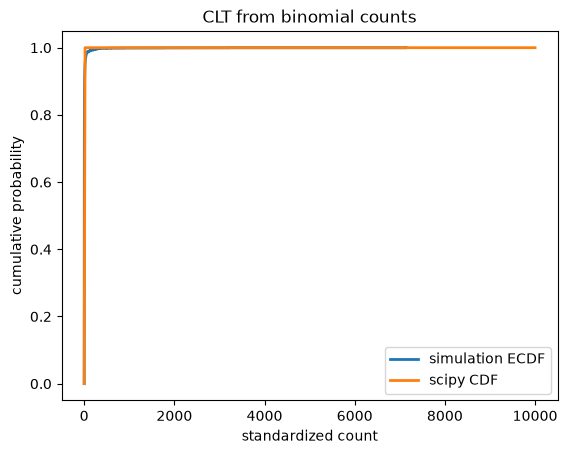

In [22]:
exp = stats.expon(0)
plot_ecdf_vs_cdf(values, exp.cdf, grid=np.linspace(0, 10000, 500), title="CLT from binomial counts", xlabel="standardized count")

As we can see above, our simulation's ECDF is very similar to the CDF of the exponential distribution. Therefore, we can conclude that this approaches the exponential distribution as $K$ increases.

Now lets take a look at the effect of changing $s$. For this demonstration, will take two samples with $K = 100{,}000$ ranks: one where $s = 1$ and one where $s = 100$. Then we will plot the two ECDFs and compare them.

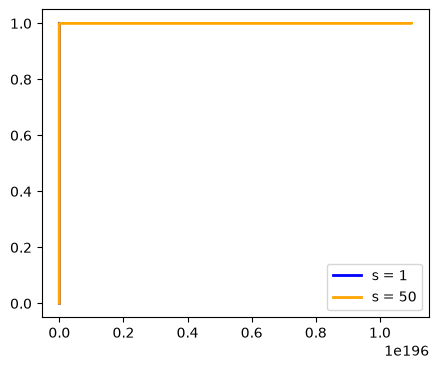

In [23]:
values = []
sA = 1
sB = 50
fig, ax = plt.subplots(figsize=(5, 4))
sizes = (k/r) ** sA

for i in range(n):
    point = int(rng.choice(r))
    size = sizes[point - 1]
    values.append(size)
    
x, y = ecdf_xy(values)
ax.step(x, y, where='post', color='blue', lw=2, label=f"s = {sA}")

values = []
sizes = (k/r) ** sB

for i in range(n):
    point = int(rng.choice(r))
    size = sizes[point - 1]
    values.append(size)
    
x, y = ecdf_xy(values)
ax.step(x, y, where='post', color='orange', lw=2, label=f"s = {sB}")
ax.legend()
plt.show()

Based on the plot above, it appears changing $s$ does not change the distribution of our ECDF. Both samples have identical exponential distributions despite the change in $s$ when $s$ is positive. Now lets try with a negative $s$ such as $-100$.

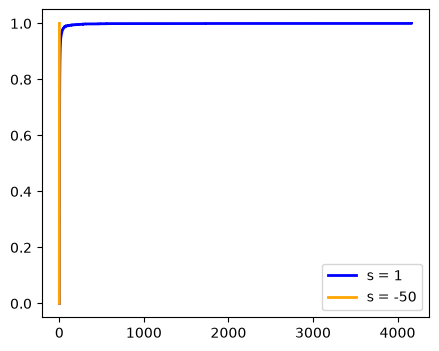

In [24]:
values = []
sA = 1
sB = -50
fig, ax = plt.subplots(figsize=(5, 4))
sizes = (k/r) ** sA

for i in range(n):
    point = int(rng.choice(r))
    size = sizes[point - 1]
    values.append(size)
    
x, y = ecdf_xy(values)
ax.step(x, y, where='post', color='blue', lw=2, label=f"s = {sA}")

values = []
sizes = (k/r) ** sB

for i in range(n):
    point = int(rng.choice(r))
    size = sizes[point - 1]
    values.append(size)
    
x, y = ecdf_xy(values)
ax.step(x, y, where='post', color='orange', lw=2, label=f"s = {sB}")
ax.legend()
plt.show()

Now we are starting to see a difference. We will take a look at $s = -10$ on its own.

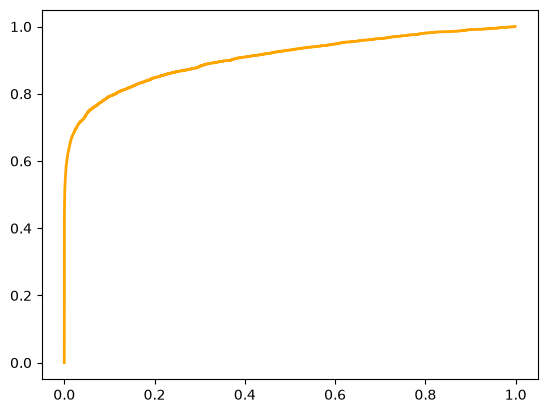

In [25]:
values = []
sizes = (k/r) ** -10

for i in range(n):
    point = int(rng.choice(r))
    size = sizes[point - 1]
    values.append(size)
    
x, y = ecdf_xy(values)
plt.step(x, y, where='post', color='orange', lw=2)

When $s$ is negative, the distribution does not reach 1 as quickly as it did with a positive value for $s$. With that being said, the distribution we are seeing here still appears to be a exponential distribution.